# Move selection model
I'm going to start to make a ResNet/CNN model, probably for training or I will use Kaggle or I'll wait the computer to work again

In [1]:
from MLChess import dataset_creation_graph, GraphAndPoolingChessGCN, ChessGCNExplainer, ChessPositionGraph
import torch.nn as nn
import torch
from torch_geometric.data import Batch
from tqdm import tqdm
import os

## Creation of the dataset

In [2]:
training, val, test = dataset_creation_graph("over_mate_1_tactic_evals.csv")

Dataset diviso in:
  Training: 1689648 campioni (70.0%)
  Validation: 362068 campioni (15.0%)
  Test: 362068 campioni (15.0%)
Dataset subset: 1689648 posizioni
Dataset subset: 362068 posizioni
Dataset subset: 362068 posizioni


In [3]:
class TestModelGCN(nn.Module):
    def __init__(self, hidden_dim: int = 256):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.GCN = GraphAndPoolingChessGCN(hidden_dim=self.hidden_dim)

        self.choose_arch = nn.Sequential(
            nn.Linear(3*self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(self.hidden_dim, 1),
        )

        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim*3 + hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    
    def forward(self, data):

        graph, combined = self.GCN(data.x, data.edge_index, data.batch, data.global_features)

        src, dst = data.edge_index
        edge_emb = torch.cat([graph[src], graph[dst], graph[dst]-graph[src]], dim=1)

        logits = self.choose_arch(edge_emb).squeeze(-1)
        if hasattr(data, "legal_edge_mask"):
            logits = logits.masked_fill(
                data.legal_edge_mask == 0, -1e9
            )

        value = self.value_head(combined)

        return logits, value

In [4]:
def save_checkpoint(model, optimizer, epoch, path, all_loss, all_policy_loss, all_value_loss):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "loss": all_loss,
        "policy_loss": all_policy_loss,
        "value_loss": all_value_loss
    }, path)


def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)
    # model.load_state_dict(checkpoint["model_state"])
    # optimizer.load_state_dict(checkpoint["optimizer_state"])
    return checkpoint

In [5]:
def policy_loss_fn(policy_logits, policy_target, legal_edge_mask):
    """
    Cross-entropy loss per la policy (VERSIONE CORRETTA)
    
    Args:
        policy_logits: [num_edges_total] logits per ogni edge nel batch
        policy_target: [num_edges_total] one-hot target (1.0 per best move)
        legal_edge_mask: [num_edges_total] maschera booleana (1=legale, 0=illegale)
    
    Returns:
        loss: scalar, cross-entropy medio per posizione
    """
    # Applica mask dura alle mosse illegali
    masked_logits = policy_logits.masked_fill(
        legal_edge_mask == 0, -1e9
    )
    
    # Log softmax
    log_probs = torch.log_softmax(masked_logits, dim=0)
    
    # Cross-entropy
    loss = -(policy_target * log_probs).sum()
    
    # FIX: conta quante posizioni hai nel batch
    # Ogni posizione ha esattamente 1 best move (1.0 in policy_target)
    num_positions = policy_target.sum().item()
    
    # Media la loss sul numero di posizioni
    return loss / num_positions

In [6]:
def train_step(model, optimizer, batch, device, lambda_policy=1.0, lambda_value=1.0):
    model.train()
    optimizer.zero_grad()
    

    # PyG batch
    data = Batch.from_data_list(batch).to(device)

    policy_logits, value = model(data)

    # --- POLICY LOSS ---
    policy_loss = policy_loss_fn(
        policy_logits,
        data.y_policy,
        data.legal_edge_mask
    )

    # --- VALUE LOSS ---
    value_loss = nn.MSELoss()
    value_loss = value_loss(
        value.squeeze(-1),
        data.y
    )

    loss = lambda_policy * policy_loss + lambda_value * value_loss

    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "policy_loss": policy_loss.item(),
        "value_loss": value_loss.item()
    }


In [ ]:
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
checkpoint_every = 5
checkpoint_dir = "./Saves_checkpoint_graph_move_and_value/"
start = 0
all_loss = []
all_policy_loss = []
all_value_loss = []

model = TestModelGCN(hidden_dim=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

'''
start_checkpoint = load_checkpoint( checkpoint_dir + "epoch_019.pt", device)
start = start_checkpoint["epoch"]
model.load_state_dict(start_checkpoint["model_state"])
optimizer.load_state_dict(start_checkpoint["optimizer_state"])
all_loss = start_checkpoint["loss"]
all_policy_loss = start_checkpoint["policy_loss"]
all_value_loss = start_checkpoint["value_loss"]
'''

for epoch in tqdm(range(start, num_epochs), total = num_epochs - start):
    epoch_loss = 0.0
    epoch_value_loss = 0.0
    epoch_policy_loss = 0.0
    n_batches = 0

    for batch in training.get_batch_iterator(shuffle=True):
        stats = train_step(model, optimizer, batch, device = device)
        epoch_loss += stats["loss"]
        epoch_value_loss += stats["value_loss"]
        epoch_policy_loss += stats["policy_loss"]
        n_batches += 1

    print(
        f"Epoch {epoch:03d} | "
        f"loss={epoch_loss / n_batches:.4f} | "
        f"policy_loss={epoch_policy_loss / n_batches:.4f} | "
        f"value_loss={epoch_value_loss / n_batches:.4f}"
    )

    all_loss.append(epoch_loss / n_batches)
    all_policy_loss.append(epoch_policy_loss / n_batches)
    all_value_loss.append(epoch_value_loss / n_batches)

    if epoch % checkpoint_every == 0:
        save_checkpoint(
            model,
            optimizer,
            epoch,
            f"{checkpoint_dir}/epoch_{epoch:03d}.pt",
            all_loss,
            all_policy_loss,
            all_value_loss
        )

save_checkpoint(
    model,
    optimizer,
    epoch,
    f"{checkpoint_dir}/epoch_{epoch:03d}.pt",
    all_loss,
    all_policy_loss,
    all_value_loss
)


cuda


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [31:47<4:46:03, 1907.06s/it]

Epoch 000 | loss=7.7879 | policy_loss=7.5384 | value_loss=0.2495


In [ ]:
# Carica il tuo modello
model = TestModelGCN(hidden_dim=256)

checkpoint_load = torch.load('./Saves_checkpoint_graph_move_and_value/epoch_009.pt')
model.load_state_dict(checkpoint_load["model_state"])

# Crea explainer
explainer = ChessGCNExplainer(model)

Salvato in position_analysis.png


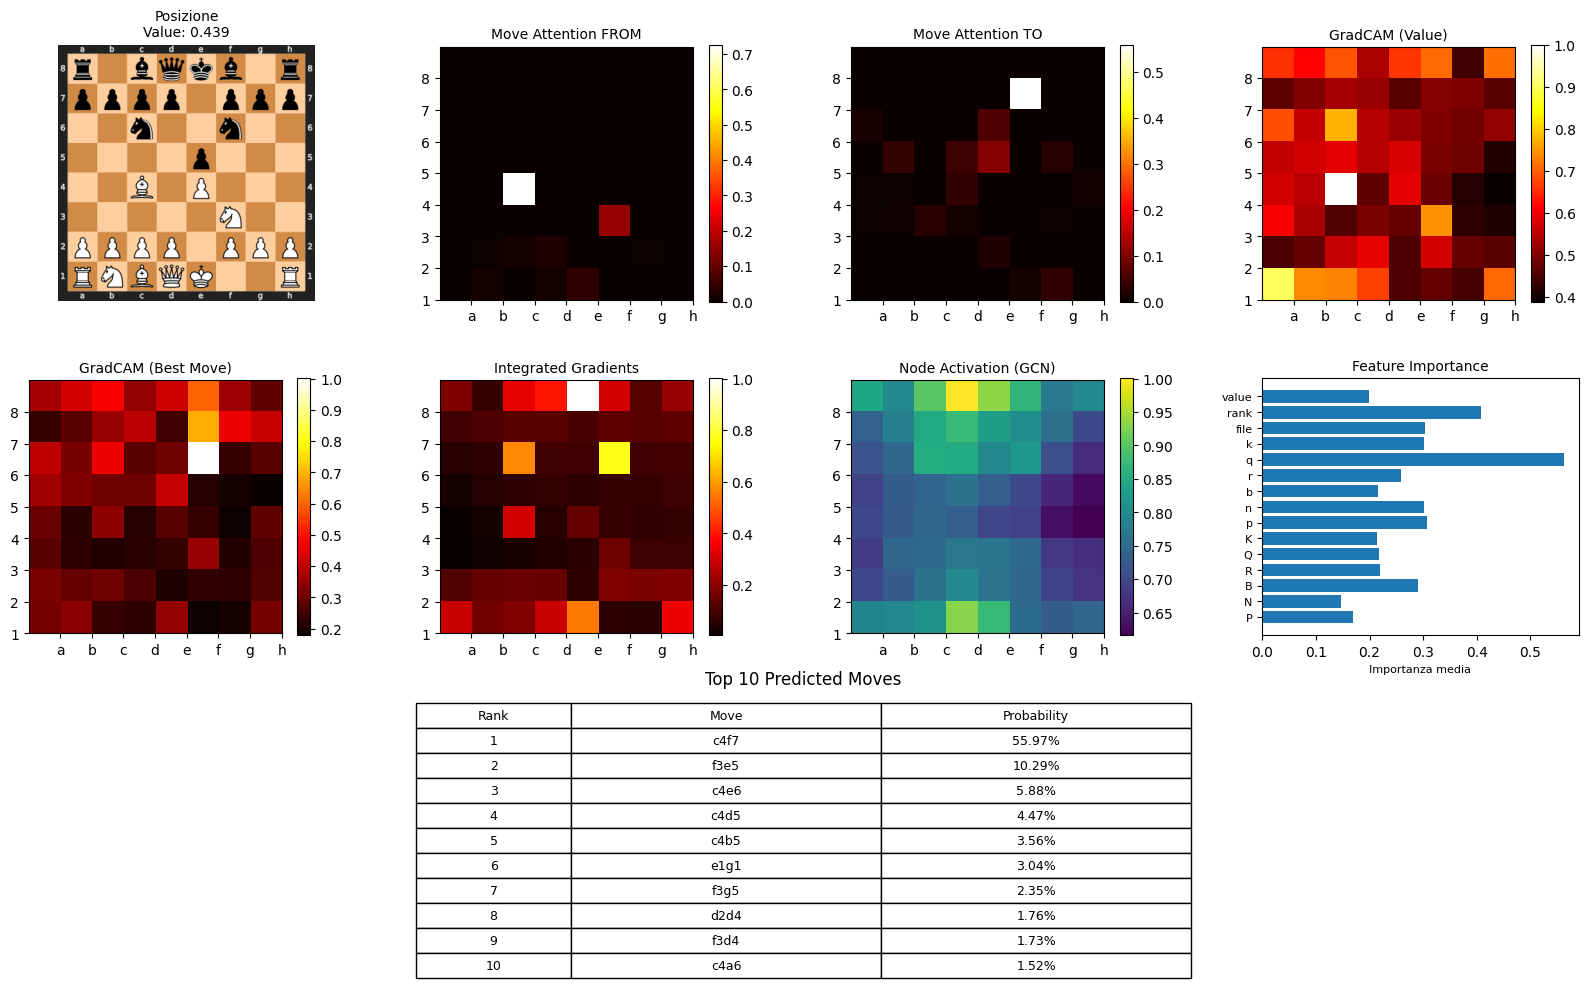

In [ ]:
import chess
import matplotlib.pyplot as plt

# Posizione interessante
board = chess.Board("r1bqkb1r/pppp1ppp/2n2n2/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 4 4")

# Converti in grafo
converter = ChessPositionGraph()
data = converter.fen_to_graph(board.fen(), "+120", "e1g1")  # esempio

# ANALISI COMPLETA (tutto in una figura)
fig = explainer.complete_analysis(data, board, save_path='position_analysis.png')
plt.show()